# DJ circuit slowly building up. 

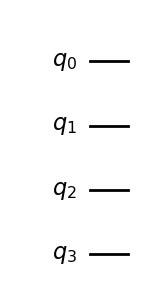

In [58]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import aer_simulator
import numpy as np 
n =3 
f0allx = QuantumCircuit(n+1) # constant oracle for f(x) = 0 for all x
# so nothing will happen to the qubits 
f0allx.draw('mpl')





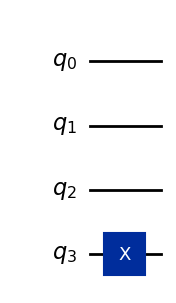

In [59]:
n=3 
f1allx = QuantumCircuit(n+1) # constant oracle for f(x) = 1 for all x
# that means we should get - at the output for all qubits. 
f1allx.x(n)
f1allx.draw('mpl')



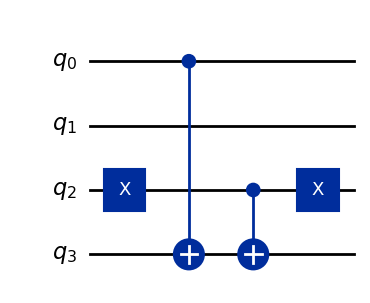

In [60]:
n=3
f01half = QuantumCircuit (n+1) # balanced oracle for f(x) = 0 for half of the inputs and f(x) = 1 for the other half
# we will use the CNOT gate to implement this.
xgates = "001"
cxgates = "101"
# Apparently it does not depend on the xgates because it undoes it before the oracle circuit ends. 
# Changing cxgats decides whether it is balanced or constant.
# Alternate bits make it balanced otherwise constant.

# Place X-gates before implenting CX in the next loop 
for i in range(n): 
    if xgates[i] == "1":
        f01half.x(i)

# place CX-gates to give phase at desired combinations
for m in range(n): 
    if cxgates[m] == "1": 
        f01half.cx(m,n)

# place X-gates after implementing CX in the previous loop
for k in range(n): 
    if xgates[k] == "1": 
        f01half.x(k)    



f01half.draw('mpl')

# add truth tables of all functions. 

# building from Deutsch algo for 2 qubits. 

In [87]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# Function to create an oracle based on the provided case
def createOracle(case):
    oracle = QuantumCircuit(2)  # Two qubits for the oracle
    if case == 1:
        oracle.x(0)  # X-gate on qubit 0
    elif case == 2:
        oracle.x(1)  # X-gate on qubit 1
    elif case == 3:
        oracle.cx(0, 1)  # Controlled-X (CNOT) gate
    elif case == 4:
        oracle.cx(0, 1)
        oracle.x(0)  # Additional X-gate on qubit 0
    return oracle


# Function to create an input state based on a binary string
def createInput(input_string):
    inputCircuit = QuantumCircuit(2)  # Two qubits for the input circuit
    for qubit, bit in enumerate(input_string):
        if bit == "1":  # Apply X-gate if the bit is 1
            inputCircuit.x(qubit)
    state = Statevector.from_instruction(inputCircuit)  # Generate the state vector
    return inputCircuit, state

# Since Deutsch's algorithm has to be hadamard in the first and last layer to work properly
def createLeadingCircuit():
    circuit = QuantumCircuit(2)
    circuit.h(0)
    circuit.h(1)
    return circuit

def createTailCircuit():
    circuit = QuantumCircuit(2)
    circuit.h(0)
    return circuit  


# Combine the leading, oracle, and tail circuits
def create_deutsch_circuit(leadingCircuit, oracle, tailCircuit):
    firstCircuit = leadingCircuit.compose(oracle)
    finalCircuit = firstCircuit.compose(tailCircuit)
    return finalCircuit


def oracle_truth_table(oracleType):
    """
    Display the truth table of the oracle in ket notation with statevectors.
    Args:
        oracleType (int): Specifies the oracle type.
    """
    # Create the oracle circuit
    oracle = createOracle(oracleType)
    
    # Iterate through all possible 2-bit inputs
    for i in range(4):  # Loop through 00, 01, 10, 11
        input_bits = format(i, "02b")  # Convert to 2-bit binary string
        inputCircuit, inputState = createInput(input_bits)
        
        # Combine the input and oracle circuits
        stitchedCircuit = inputCircuit.compose(oracle)
        statevector = Statevector.from_instruction(stitchedCircuit)
        
        # Display input in ket notation and the corresponding statevector
        display(Math(f"\\text{{Input: }} |{input_bits}\\rangle"))
        display(statevector.draw('latex'))




# Run 


# Oracle type and input binary string
oracleType = 4
input_string = "00"

# Create the oracle and input circuits
oracle = createOracle(oracleType)
inputCircuit, inputState = createInput(input_string)

oracleType = 4 
oracle_truth_table(oracleType)

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

# DJ Algo with 3 qubits 


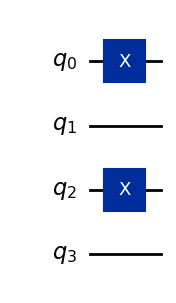

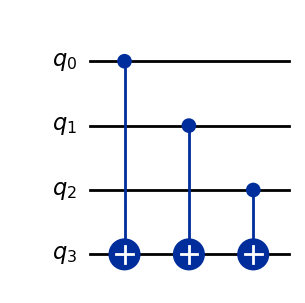

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

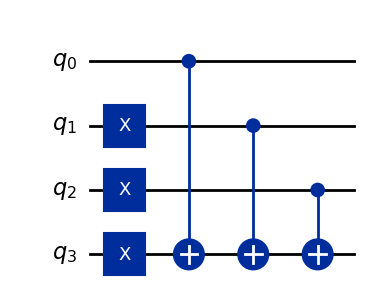

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# Function to create an oracle based on the provided case
def createOracle(case):
    oracle = QuantumCircuit(4)  # Two qubits for the oracle
    if case == 1:
        oracle.x(0)  # X-gate on qubit 0
        oracle.x(2)
    elif case == 2:
        oracle.x(1)  # X-gate on qubit 1
        oracle.x(0)
    elif case == 3:
        oracle.cx(0, 3)  # Controlled-X (CNOT) gate
        oracle.cx(2, 3)
    elif case == 4:
        for i in range(3):
            oracle.cx(i,3) 
        
    return oracle


# Function to create an input state based on a binary string
def createInput(input_string):
    inputCircuit = QuantumCircuit(4)  # Two qubits for the input circuit
    for qubit, bit in enumerate(input_string):
        if bit == "1":  # Apply X-gate if the bit is 1
            inputCircuit.x(qubit)
    state = Statevector.from_instruction(inputCircuit)  # Generate the state vector
    return inputCircuit, state

# Since Deutsch's algorithm has to be hadamard in the first and last layer to work properly
def createLeadingCircuit():
    circuit = QuantumCircuit(4)
    circuit.h(0)
    circuit.h(1)
    circuit.h(2)
    circuit.x(3)  # flip last bit to 1 for DJ algo
    circuit.h(3) 
    return circuit

def createTailCircuit():
    circuit = QuantumCircuit(4)
    circuit.h(0)
    circuit.h(1)
    circuit.h(2) 
    return circuit  


# Combine the leading, oracle, and tail circuits
def create_deutsch_circuit(leadingCircuit, oracle, tailCircuit):
    firstCircuit = leadingCircuit.compose(oracle)
    finalCircuit = firstCircuit.compose(tailCircuit)
    return finalCircuit


def oracle_truth_table(oracleType):
    """
    Display the truth table of the oracle in ket notation with statevectors.
    Args:
        oracleType (int): Specifies the oracle type.
    """
    # Create the oracle circuit
    oracle = createOracle(oracleType)
    
    # Iterate through all possible 3-bit inputs
    for i in range(8):  # Loop through 000, 010, 101, 110 and so on for 8 combinations
        input_bits = format(i, "04b")  # Convert to 2-bit binary string
        inputCircuit, inputState = createInput(input_bits)
        
        # Combine the input and oracle circuits
        stitchedCircuit = inputCircuit.compose(oracle)
        statevector = Statevector.from_instruction(stitchedCircuit)
        
        # Display input in ket notation and the corresponding statevector
        display(Math(f"\\text{{Input: }} |{input_bits}\\rangle"))
        display(statevector.draw('latex'))
    return inputCircuit,stitchedCircuit







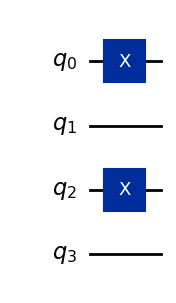

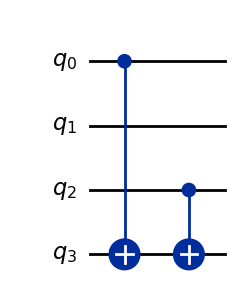

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

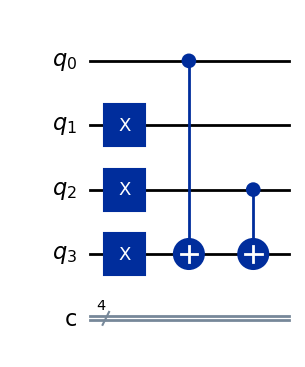

balanced


In [102]:
# Run 

# Oracle type and input binary string
oracleType = 3
input_string = "101"

# Create the oracle and input circuits
oracle = createOracle(oracleType)


inputCircuit, inputState = createInput(input_string)
display(inputCircuit.draw('mpl'))
display(oracle.draw('mpl'))

inputCircuit, stitchedCircuit = oracle_truth_table(oracleType)



# check if oracle is balanced or constant. 
# Runs the circuit 100 times. if the measurements are all 0 strings it is constant. otherwise if even one 1 present it is balanced. 


qc = QuantumCircuit(4,4)
final = qc.compose(stitchedCircuit)
display(final.draw('mpl'))
final.measure(range(4), range(4))
result = AerSimulator().run(final, shots=1, memory=True).result()
measurements = result.get_memory()
if "1" in measurements[0]:
    print("balanced")
else: 
    print("constant")




In [111]:
# Attempt of just Deutsch algorithm 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

# Function to create an oracle for 3 qubits
def createOracle(case):
    oracle = QuantumCircuit(4)
    if case == 1:  # Constant function (always 0)
        pass  # No operation needed
    elif case == 2:  # Constant function (always 1)
        oracle.x(3)  # Flip the ancillary qubit
    elif case == 3:  # Balanced function
        oracle.cx(0, 3)
        oracle.cx(2, 3)
    elif case == 4:  # Another balanced function
        for i in range(3):
            oracle.cx(i, 3)
    return oracle

# Function to create the Deutsch-Jozsa circuit
def deutschJozsa(oracle):
    # Create a quantum circuit with 3 working qubits and 1 ancillary qubit
    dj_circuit = QuantumCircuit(4, 3)

    # Step 1: Initialize input qubits in superposition
    dj_circuit.h(0)
    dj_circuit.h(1)
    dj_circuit.h(2)

    # Initialize ancillary qubit in |1⟩ state and apply Hadamard
    dj_circuit.x(3)
    dj_circuit.h(3)

    # Step 2: Apply the oracle
    dj_circuit.compose(oracle, inplace=True)

    # Step 3: Apply Hadamard gates to the input qubits
    dj_circuit.h(0)
    dj_circuit.h(1)
    dj_circuit.h(2)

    # Step 4: Measure the first 3 qubits
    dj_circuit.measure(range(3), range(3))

    return dj_circuit

# Test the Deutsch-Jozsa algorithm
oracleType = 4  # Change this to test different oracles
oracle = createOracle(oracleType)
dj_circuit = deutschJozsa(oracle)




# # Determine if the oracle is balanced or constant
# print("Measurement Results:", counts)
# if "000" in counts:
#     print("The oracle is constant.")
# else:
#     print("The oracle is balanced.")
